## <center>CITS5508 Lab sheet 2: Implementing a simple classification task</center>

This is an example notebook to help you implement the tasks required for this lab sheet. 

We have provided some ideas to help you. Use the unit content and your thinking to create the several necessary steps. 

You will develop Python code for a simple classification task in this lab sheet. Certify that the presentation of your Python notebook is good and that you used the Markdown cells well. Make sure you properly format your plots and results. For instance, all your diagrams/plots should have proper axis labels and titles to help the reader understand what you are plotting. Another example is the confusion matrix; not showing the class names makes the confusion matrix completely useless. Use the lab sheets to learn how to improve the presentation of your notebook, as you will need this in the assessments. 

### Importing the libraries

In [1]:
#You may need to add other libraries here depending on your code

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# to display plots in Jupyter notebook
%matplotlib inline

plt.rcParams['font.size'] = '12'

### 1. Loading the data

Load the data and create your training and test datasets.

In [2]:
#load the dataset from github repository, files are in the W3 folder of the repository training.csv and testing.csv respectively
file_dir = 'https://raw.githubusercontent.com/somid05/ML-2026/main/W3/'
df_train = pd.read_csv(file_dir + 'training.csv')
df_test = pd.read_csv(file_dir + 'testing.csv')

### 2. Quick inspecting the data

Inspect what the columns are. Try the different options as discussed in lectures (e.g. head() and info() functions). Don't forget to use appropriate formatting in your output answers. What can you observe? Are there any issues with the data?

In [3]:
column_headings = df_train.columns

#format your print, e.g.
print('Column headings are:','\n'.join(column_headings))

Column headings are: class
b1
b2
b3
b4
b5
b6
b7
b8
b9
pred_minus_obs_H_b1
pred_minus_obs_H_b2
pred_minus_obs_H_b3
pred_minus_obs_H_b4
pred_minus_obs_H_b5
pred_minus_obs_H_b6
pred_minus_obs_H_b7
pred_minus_obs_H_b8
pred_minus_obs_H_b9
pred_minus_obs_S_b1
pred_minus_obs_S_b2
pred_minus_obs_S_b3
pred_minus_obs_S_b4
pred_minus_obs_S_b5
pred_minus_obs_S_b6
pred_minus_obs_S_b7
pred_minus_obs_S_b8
pred_minus_obs_S_b9


### 3. Removing some columns from the dataset

We are going to drop all the columns *pred_minus_obs...*, i.e., we keep only the first 10 columns: the *class* column and the columns b1, b2, ..., b9. Don't forget to apply these changes to the training and test sets. 

In [4]:
#You need to create a code to remove the undesired columns from the training and testing sets. After that,
#inspect what your datasets look like. Do you have the correct data matrix structure (that is, rows represent the examples 
#and columns represent the attributes?

def clean_cols(df: pd.DataFrame) -> pd.DataFrame:
    return df[['class'] + [f'b{i}' for i in range(1, 10)]]

df_train = clean_cols(df_train)
df_test = clean_cols(df_test)

### 4. Counting the number of instances in each class

According to the UCI Machine Learning website, this dataset has 4 class labels given in the first column of the csv file: Class: *s* ('Sugi' forest), *h* ('Hinoki' forest), *d* ('Mixed deciduous' forest), *o* ('Other' non-forest land). Write Python code to count instances/examples for each class label in your datasets. Are they imbalanced? 

In [5]:
print('train', df_train['class'].value_counts())
print('test', df_test['class'].value_counts())

train class
s    136
d    105
o     46
h     38
Name: count, dtype: int64
test class
s    59
d    54
h    48
o    37
Name: count, dtype: int64


### 5. Doing some data visualisation 

Use appropriate functions to display (visualise) the different features (attributes/columns). You can also incorporate class information. Do you observe any aspect of the data that should be addressed?

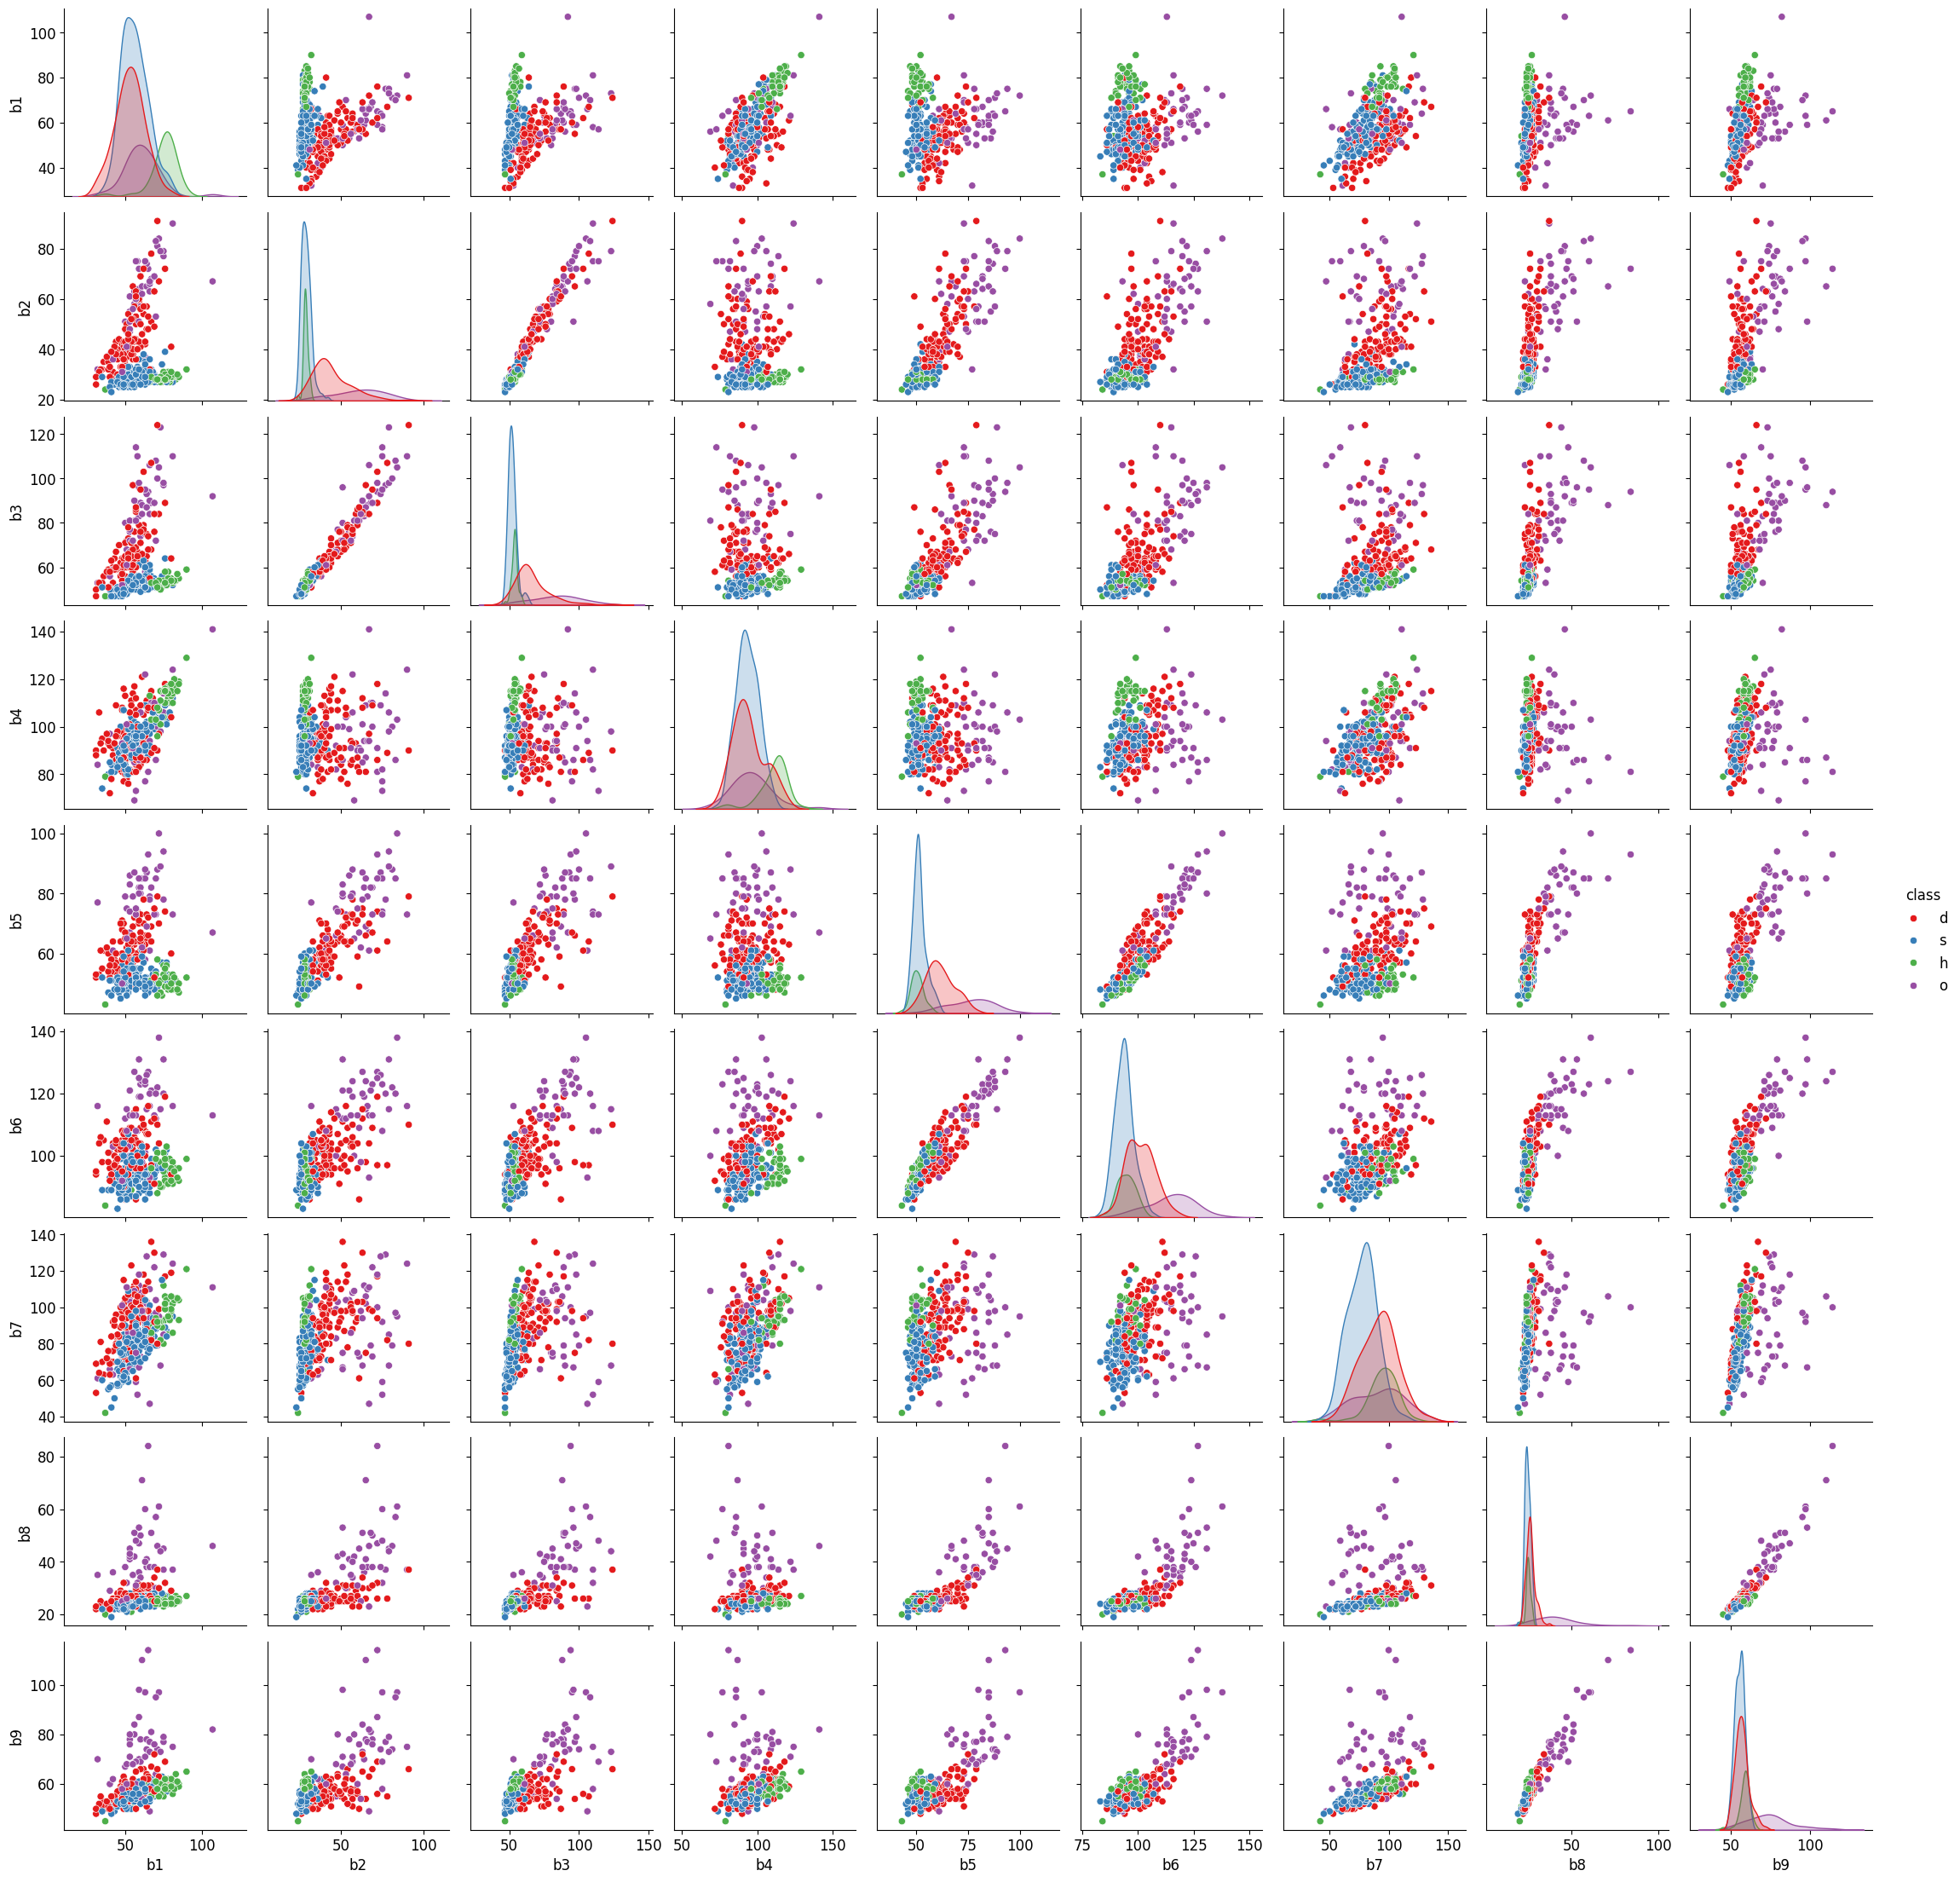

In [6]:
#pairwise scatter plot of the attributes in the training set, use seaborn library
import seaborn as sns

#separate the classess with different colors in the pairwise scatter plot, use seaborn library
sns.pairplot(df_train, hue='class', palette='Set1')
plt.show()

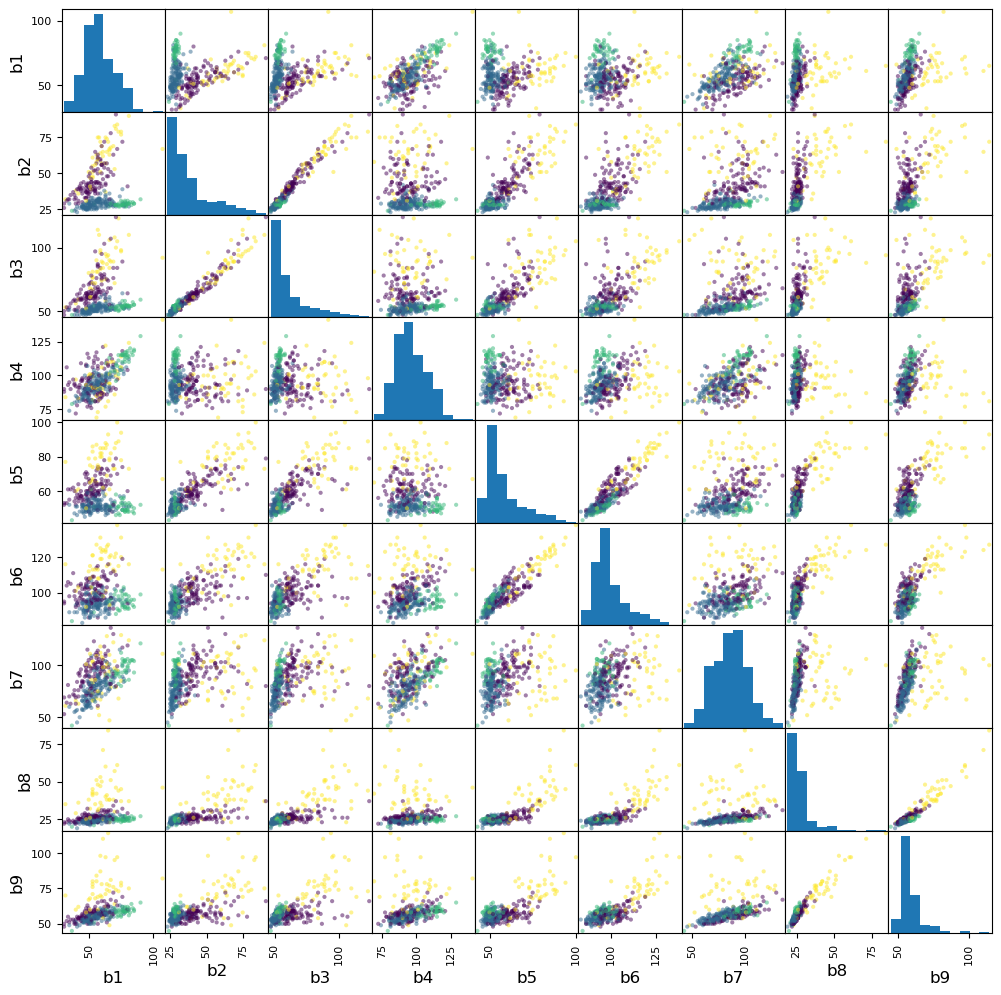

In [ ]:
# Tip: explore different options, like histograms, scatter plots, etc. 
from pandas.plotting import scatter_matrix

class_labels, _ = pd.factorize(df_train['class'])
df_features = df_train[[f'b{i}' for i in range(1, 10)]]

# just one example, simple scatter_matrix with pandas
scatter_matrix(df_features, figsize=(12, 12), diagonal='hist', alpha=0.5, c=class_labels)
plt.show()

### 6. Preparing the data for a binary classification

We will do a multiclass classification on this dataset later. For now, we will start with a binary classification. Update your training and testing sets to contain only examples from two classes: "s" ("Sugi" forest) and  "d" ("Mixed deciduous" forest).

In [7]:
def remove_classes(df: pd.DataFrame, classes_to_keep=['s', 'd']) -> pd.DataFrame:
    return df[df['class'].isin(classes_to_keep)]

df_train = remove_classes(df_train)
df_test = remove_classes(df_test)

print('train', df_train['class'].value_counts())
print('test', df_test['class'].value_counts())

train class
s    136
d    105
Name: count, dtype: int64
test class
s    59
d    54
Name: count, dtype: int64


### 7. Using the Logistic Regression

Use the **Logistic Regression Classifier** implemented in **sklearn.linear\_model** class to perform a binary classification on the updated datasets. Try also to implement your version of the Logistic Regression (do you arrive at similar results as the package?). Implementing your version is the best way to learn. 

In [8]:
X_train, y_train = df_train[[f'b{i}' for i in range(1, 10)]], df_train['class']
X_test, y_test = df_test[[f'b{i}' for i in range(1, 10)]], df_test['class']

In [9]:
# we actually do want to scale features here
# (for SGD + I am not using numerically stable sigmoid)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# NOTE: careful -- fit_transform for train, transform for test
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression
sklearn_clf = LogisticRegression(random_state=42, max_iter=1000).fit(X_train, y_train)

In [11]:
class LogisticRegressionSGD:
    def __init__(self, lr=0.01, max_iter=1000, random_state=42):
        self.lr = lr
        self.max_iter = max_iter
        self._rng = np.random.default_rng(random_state)

    def _sigmoid(self, x):
        # NOTE: careful, not numerically stable
        #       (should be ok for here)                                             
        return 1 / (1 + np.exp(-x))                                     
    
    def fit(self, X, y):
        # support string labels
        self.classes_ = np.unique(y)                                    
        self.label_map = {c: i for i, c in enumerate(self.classes_)}

        # integer encode
        y = np.vectorize(self.label_map.get)(y)                         

        # bias term
        X = np.c_[np.ones(X.shape[0]), X]                               

        # zero initialise weights  
        self.w = np.zeros(X.shape[1])                                           
        
        for i in range(self.max_iter):
            # pick random example
            idx = self._rng.integers(low=0, high=X.shape[0])            
            
            x_i, y_i = X[idx], y[idx]
            
            # update weights
            grad = (self._sigmoid(np.dot(x_i, self.w)) - y_i) * x_i    
            self.w -= self.lr * grad
        
        # return self so `clf = LogisticRegressionSGD().fit(...)` works
        # (like sklearn example above)
        return self                                                     

    def predict_proba(self, X):
        
        # add bias term
        X = np.c_[np.ones(X.shape[0]), X]                               

        probs = self._sigmoid(np.dot(X, self.w))
        
        # return 2D array of shape (n_samples, n_classes) to match sklearn's output format
        return np.c_[1 - probs, probs]                                  
    
    def predict(self, X, threshold = 0.5):
        # cast back into class strings
        return np.vectorize({v: k for k, v in self.label_map.items()}.get)(
            (self.predict_proba(X)[:, 1] >= threshold).astype(int)
        )

sgd_clf = LogisticRegressionSGD().fit(X_train, y_train)

### 8. Inspecting performance indicators

Write Python code to show results for: 

- The accuracy values for the training set and the test set.
- The confusion matrix on the training and testing set.  
- The plot of precision versus recall for the training set.

Make sure you format the output properly. 

In [12]:
from sklearn.metrics import accuracy_score
print(f'sklearn accuracy (train): {accuracy_score(y_train, sklearn_clf.predict(X_train)):.2f}')
print(f'custom SGD accuracy (train): {accuracy_score(y_train, sgd_clf.predict(X_train)):.2f}')
print(f'sklearn accuracy (test): {accuracy_score(y_test, sklearn_clf.predict(X_test)):.2f}')
print(f'custom SGD accuracy (test): {accuracy_score(y_test, sgd_clf.predict(X_test)):.2f}')

sklearn accuracy (train): 0.96
custom SGD accuracy (train): 0.94
sklearn accuracy (test): 0.99
custom SGD accuracy (test): 0.98


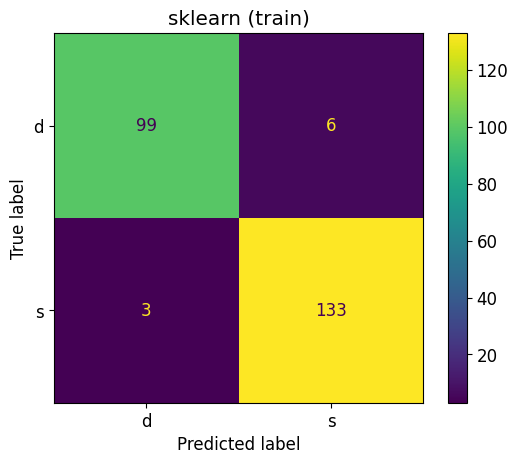

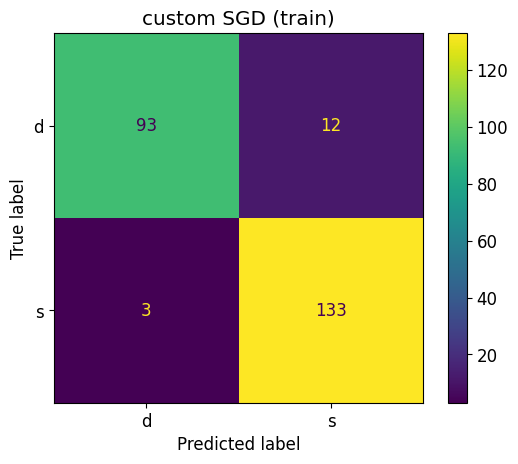

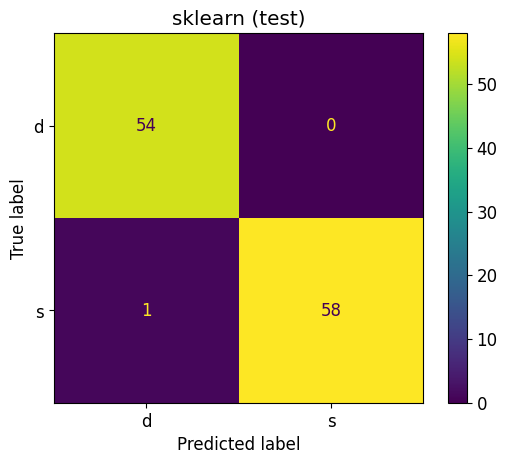

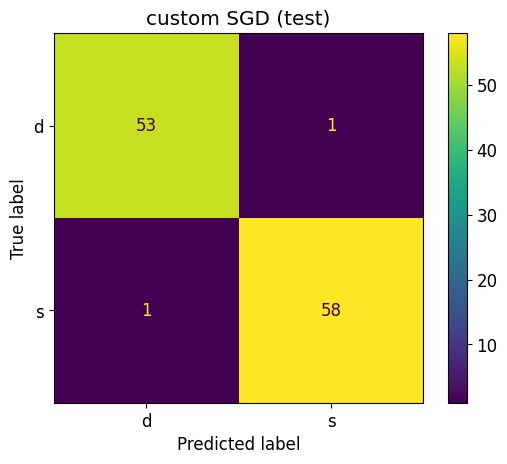

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(y_train, sklearn_clf.predict(X_train))
disp.ax_.set_title('sklearn (train)')
disp = ConfusionMatrixDisplay.from_predictions(y_train, sgd_clf.predict(X_train))
_ = disp.ax_.set_title('custom SGD (train)')

disp = ConfusionMatrixDisplay.from_predictions(y_test, sklearn_clf.predict(X_test))
disp.ax_.set_title('sklearn (test)')
disp = ConfusionMatrixDisplay.from_predictions(y_test, sgd_clf.predict(X_test))
_ = disp.ax_.set_title('custom SGD (test)')

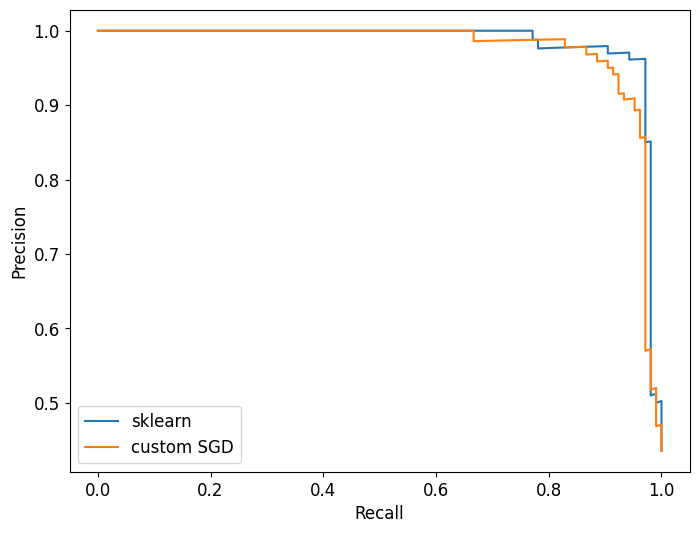

In [14]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))
precision, recall, thresholds = precision_recall_curve(y_train=='d', sklearn_clf.predict_proba(X_train)[:, 0])
plt.plot(recall, precision, label='sklearn')
precision, recall, thresholds = precision_recall_curve(y_train=='d', sgd_clf.predict_proba(X_train)[:, 0])
plt.plot(recall, precision, label='custom SGD')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

### *Optional, but may be covered in assessments.*

### 9. Plotting the estimated probabilities and decision boundary of the Logistic Regression model. 

Consider two individual features in our dataset. We will use them to examine the estimated probabilities and decision boundary of the Logistic Regression model. You can choose which ones and/or experiment with different pairs of features. For each pair, you should create a new version of your training set using these two features only.

Also, to plot the Logistic Regression Classifier's estimated probabilities and decision boundary (as in Figure 4.23 of the textbook), considering these two individual features, you will need to create a Logistic Regression model for each feature. Hence, you are to provide two plots.

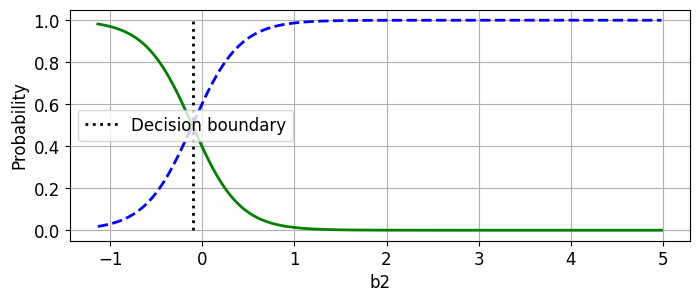

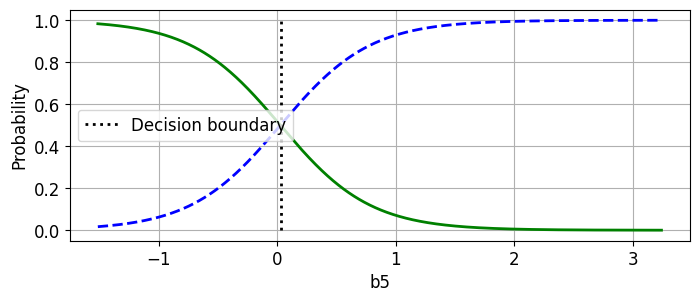

In [15]:
# see: https://github.com/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb
for feat in ['b2', 'b5']:
    X_train_new = df_train[[feat]]
    X_test_new = df_test[[feat]]

    scaler_new = StandardScaler()
    X_train_new = scaler.fit_transform(X_train_new)
    X_test_new = scaler.transform(X_test_new)

    log_reg = LogisticRegression(random_state=42).fit(X_train_new, y_train)

    X_new = np.linspace(X_train_new.min(), X_train_new.max(), 1000).reshape(-1, 1)
    y_proba = log_reg.predict_proba(X_new)
    decision_boundary = X_new[y_proba[:, 0] >= 0.5][0, 0]

    plt.figure(figsize=(8, 3))
    plt.plot(X_new, y_proba[:, 0], 'b--', linewidth=2, label='')
    plt.plot(X_new, y_proba[:, 1], 'g-', linewidth=2, label='')
    plt.plot([decision_boundary, decision_boundary], [0, 1], 'k:', linewidth=2, label='Decision boundary')

    plt.xlabel(feat)
    plt.ylabel('Probability')
    plt.legend(loc='center left')
    plt.grid()

Based on your plots, comment about: 

- What threshold would you choose for classification based on the predicted probabilities?
- What is the impact of changing the threshold for performance indicators such as precision and recall?
- What can you say about the overlap between classes, and how does this impact classification performance?

W3

In [ ]:
#split training set into training and validation sets, use sklearn's train_test_split function
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(X_train, X_val, test_size=0.2, random_state=42)


In [ ]:
X_train.head()

In [ ]:
#use sklearn SGDClassifier with grid search to find the best hyperparameters, use sklearn's GridSearchCV function
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'max_iter': [1000, 2000, 5000],
}

sgd_clf = SGDClassifier(random_state=42)
grid_search = GridSearchCV(sgd_clf, param_grid, cv=5)
grid_search.fit(X_train, X_val)